In [1]:
import pennylane as qp
qml = qp
import numpy as np

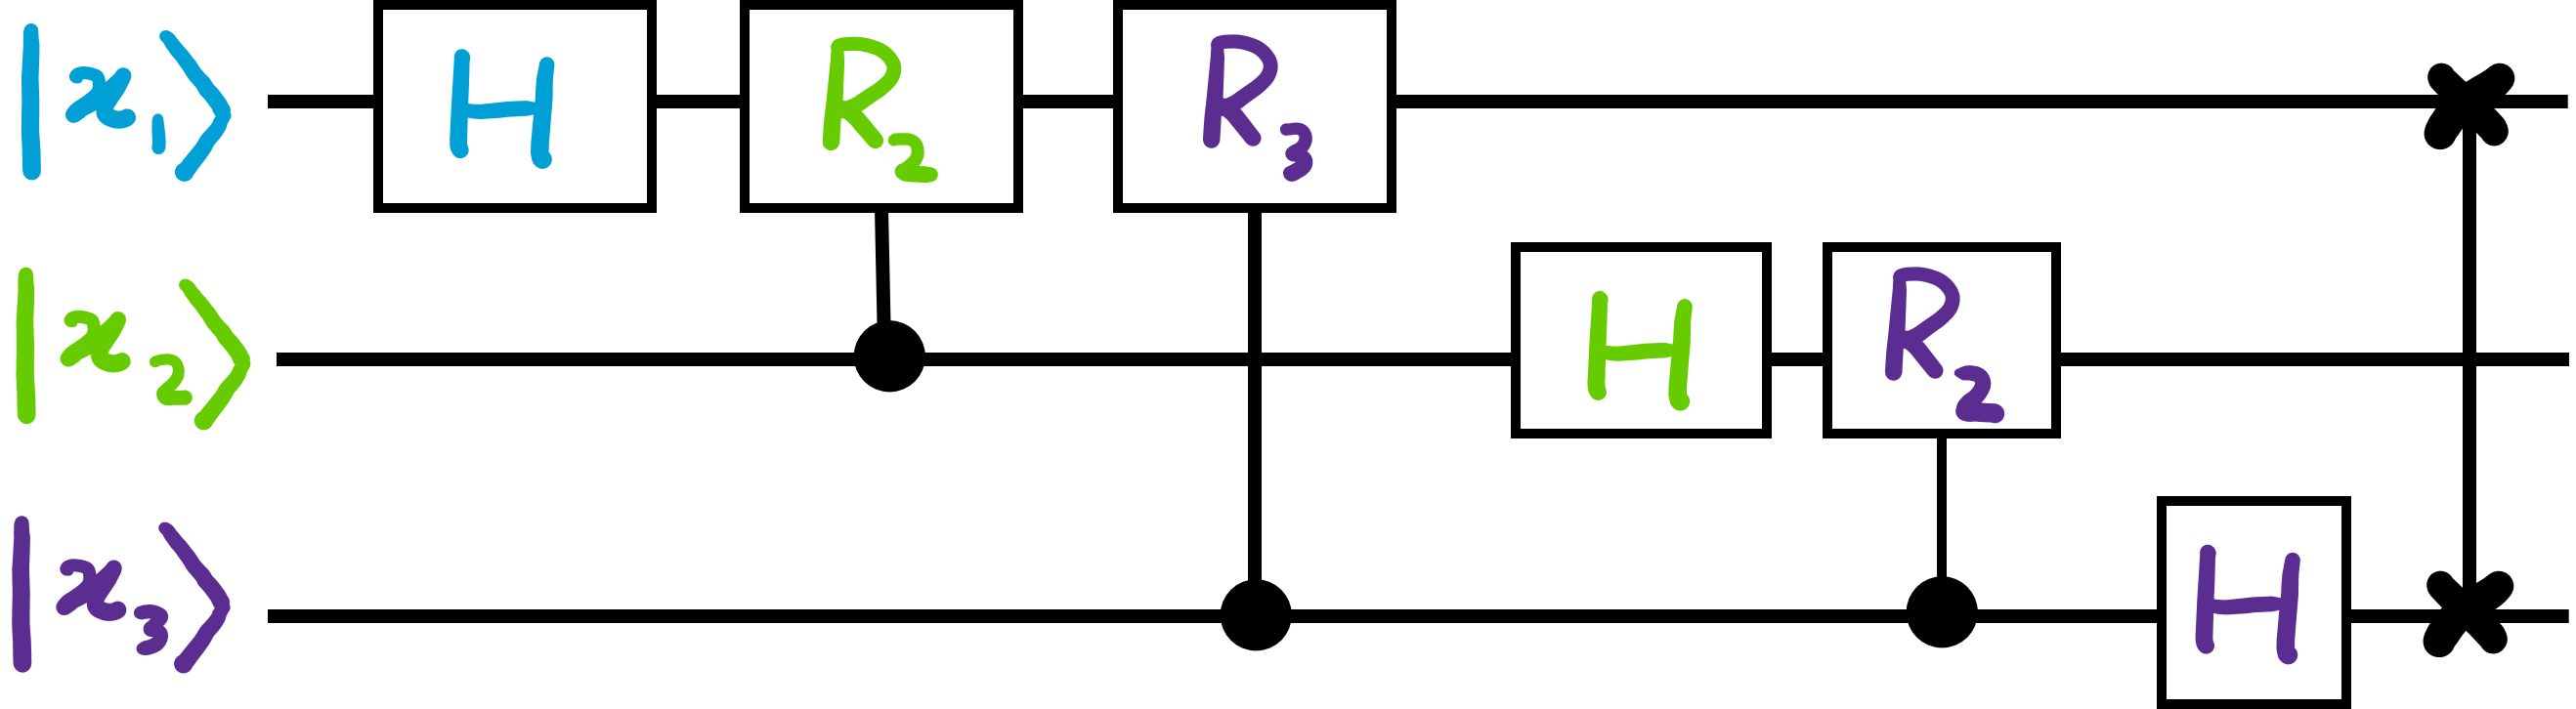

In [2]:
num_wires = 3
dev = qp.device("default.qubit", wires=num_wires)

@qp.qnode(dev)
def three_qubit_QFT(basis_id):
    """A circuit that computes the QFT on three qubits.
    
    Args:
        basis_id (int): An integer value identifying the basis state to construct.
        
    Returns:
        array[complex]: The state of the qubits after the QFT operation.
    """
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=num_wires)]
    qp.BasisState(bits, wires=[0, 1, 2])
    
    ##################
    # YOUR CODE HERE #
    ################## 
    qp.Hadamard(wires=0)
    qp.ctrl(qp.S(wires=0), control=1)
    qp.ctrl(qp.T(wires=0), control=2)
    
    qp.Hadamard(wires=1)
    qp.ctrl(qp.S(wires=1), control=2)
    
    qp.Hadamard(wires=2)
    
    qp.SWAP(wires=[0,2])

    return qp.state()

In [3]:
dev = qp.device('default.qubit', wires=4)

def swap_bits(n_qubits):
    """A circuit that reverses the order of qubits, i.e.,
    performs a SWAP such that [q1, q2, ..., qn] -> [qn, ... q2, q1].
    
    Args:
        n_qubits (int): An integer value identifying the number of qubits.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    for qubit in range(n_qubits//2):
        qp.SWAP(wires=[qubit, n_qubits-qubit-1])

@qp.qnode(dev) 
def qft_node(basis_id, n_qubits):
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qp.BasisState(bits, wires=range(n_qubits))
    # qft_rotations(n_qubits)
    swap_bits(n_qubits)
    return qp.state()

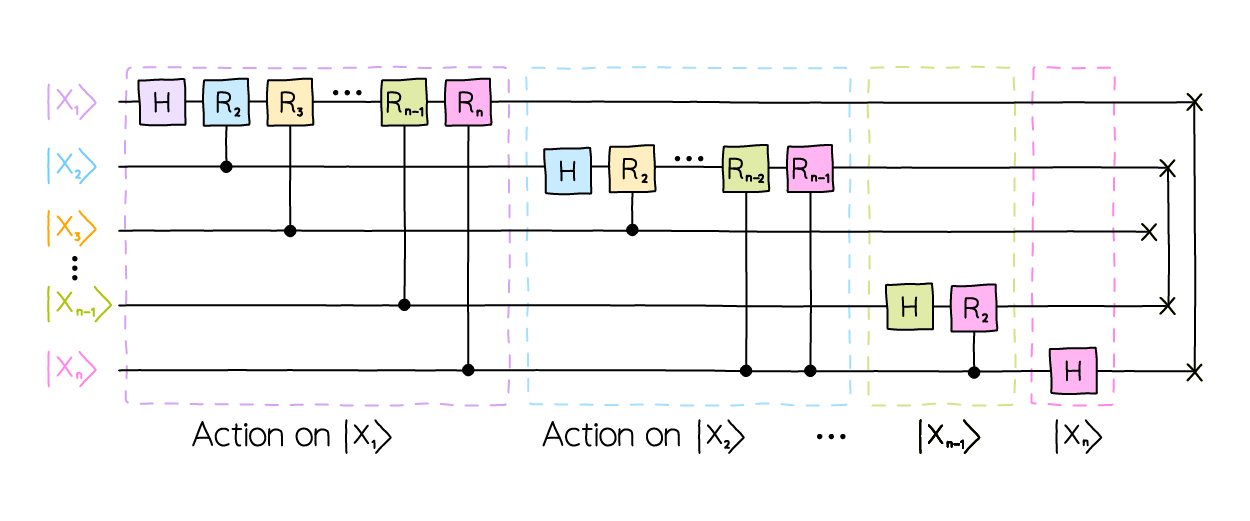

In [4]:
dev = qp.device('default.qubit', wires=4)

def qft_rotations(n_qubits):
    """A circuit performs the QFT rotations on the specified qubits.
    
    Args:
        n_qubits (int): An integer value identifying the number of qubits.
    """

    ##################
    # YOUR CODE HERE #
    ################## 
    for qubit in range(n_qubits):
        qp.Hadamard(wires=qubit)
        for next_qubit in range(qubit+1, n_qubits):
            qp.ControlledPhaseShift(np.pi/2**(next_qubit-qubit), wires=[next_qubit, qubit])

@qp.qnode(dev) 
def qft_node(basis_id, n_qubits):
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qp.BasisState(bits, wires=range(n_qubits))
    qft_rotations(n_qubits)
    swap_bits(n_qubits)
    return qp.state()

In [5]:
dev = qp.device('default.qubit', wires=4)

def qft_recursive_rotations(n_qubits, wire=0):
    """A circuit that performs the QFT rotations on the specified qubits
        recursively.
        
    Args:
        n_qubits (int): An integer value identifying the number of qubits.
        wire (int): An integer identifying the wire 
                    (or the qubit) to apply rotations on.
    """

    ##################
    # YOUR CODE HERE #
    ################## 
    if (wire==n_qubits):
        return
    
    qp.Hadamard(wires=wire)

    for qubit in range(wire+1, n_qubits):
        qp.ControlledPhaseShift(np.pi/2**(qubit -wire), wires=[qubit, wire]) 
    qft_recursive_rotations(n_qubits, wire+1)

@qp.qnode(dev) 
def qft_node(basis_id, n_qubits):
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qp.BasisState(bits, wires=range(n_qubits))
    qft_recursive_rotations(n_qubits)
    swap_bits(n_qubits)
    return qp.state()

In [6]:
dev = qp.device('default.qubit', wires=4)

@qp.qnode(dev)
def pennylane_qft(basis_id, n_qubits):
    """A that circuit performs the QFT using PennyLane's QFT template.
    
    Args:
        basis_id (int): An integer value identifying 
            the basis state to construct.
        n_qubits (int): An integer identifying the 
            number of qubits.
            
    Returns:
        array[complex]: The state after applying the QFT to the qubits.
    """
    # Prepare the basis state |basis_id>
    bits = [int(x) for x in np.binary_repr(basis_id, width=n_qubits)]
    qp.BasisState(bits, wires=range(n_qubits))

    ##################
    # YOUR CODE HERE #
    ################## 
    qp.QFT(wires=range(n_qubits))

    return qp.state()